Sampled dataset shape: (130606, 13)

Target distribution:
Delay
0    100663
1     26172
Name: count, dtype: int64

Best Parameters
Logistic Regression: {'max_iter': 1000, 'class_weight': 'balanced', 'C': 10}
Random Forest: {'n_estimators': 120, 'min_samples_split': 2, 'max_depth': 12, 'class_weight': None}
XGBoost: {'subsample': 0.8, 'n_estimators': 120, 'max_depth': 5, 'learning_rate': 0.1}

Detailed Results
                 Model  Accuracy  Precision  Recall     F1    AUC
2              XGBoost     0.794      0.586   0.011  0.022  0.658
1        Random Forest     0.794      0.684   0.002  0.005  0.657
0  Logistic Regression     0.614      0.290   0.601  0.391  0.650

Logistic Regression - Classification Report
              precision    recall  f1-score   support

           0      0.856     0.617     0.717     20133
           1      0.290     0.601     0.391      5234

    accuracy                          0.614     25367
   macro avg      0.573     0.609     0.554     25367
weight

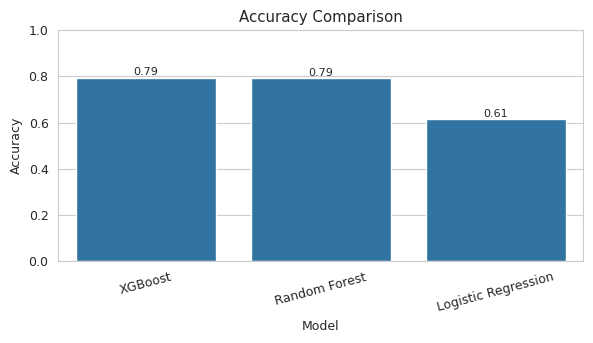

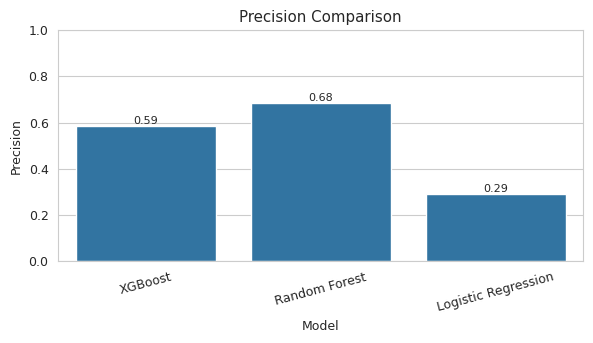

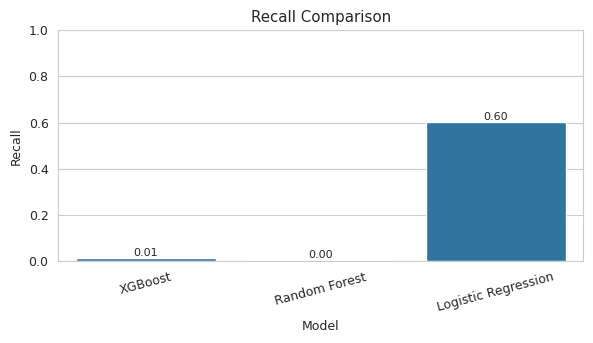

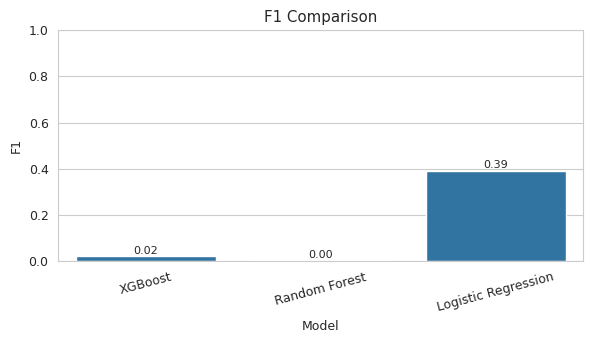

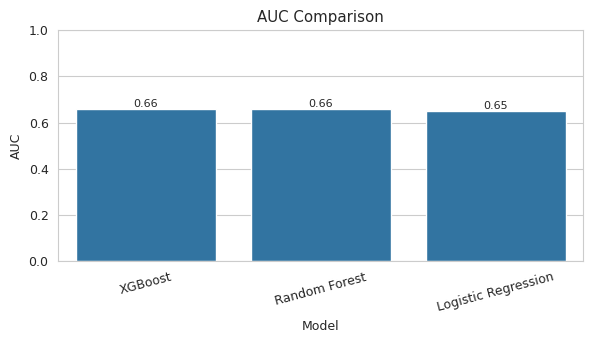

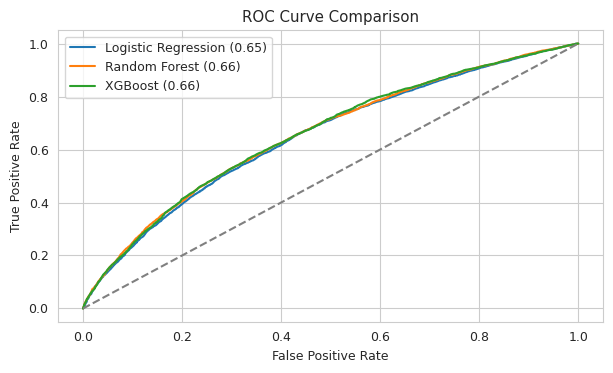

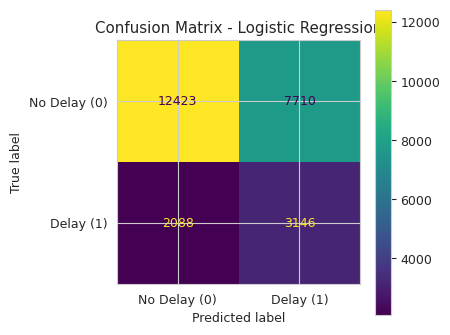

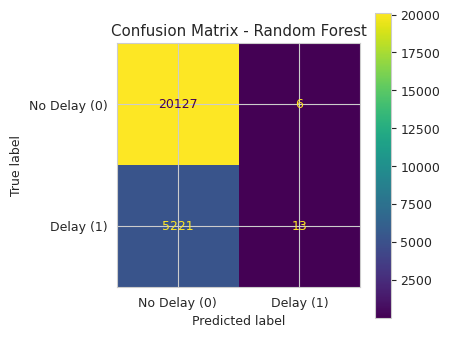

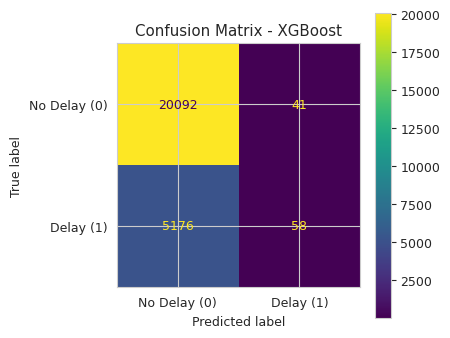

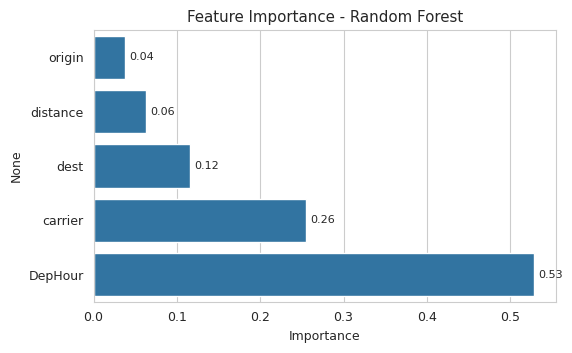


Feature Importance - Random Forest
origin      0.038
distance    0.063
dest        0.116
carrier     0.255
DepHour     0.528
dtype: float64


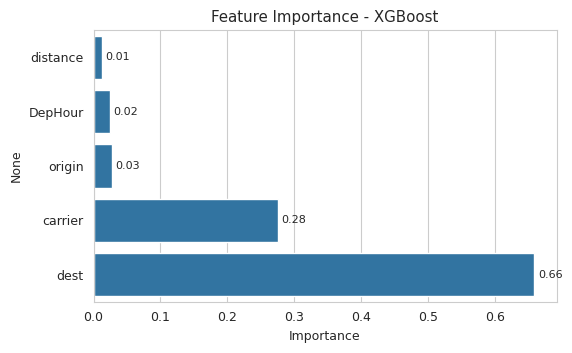


Feature Importance - XGBoost
distance    0.013
DepHour     0.025
origin      0.027
carrier     0.276
dest        0.659
dtype: float32


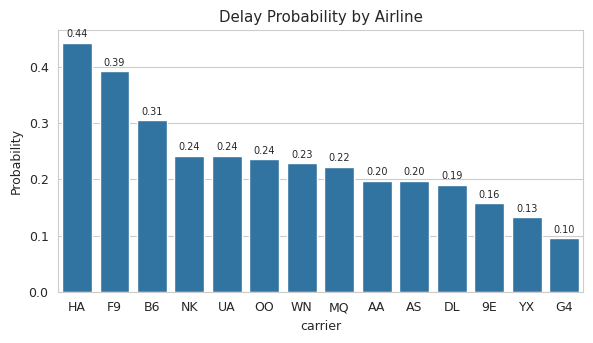

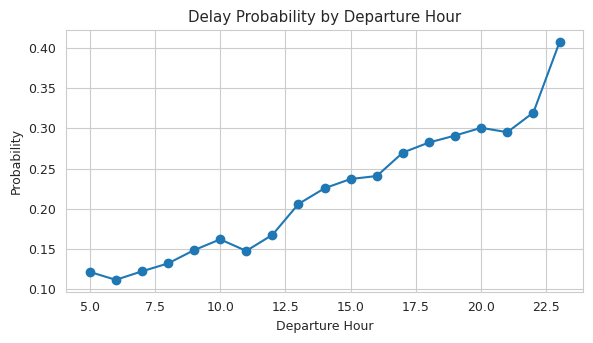

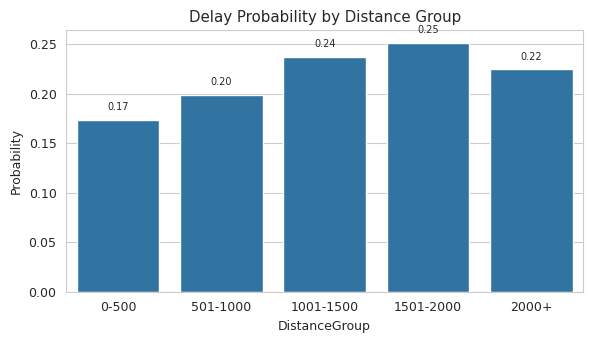

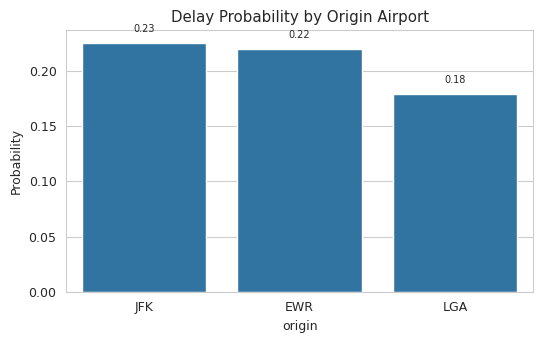


Delay Probability by Airline
carrier
HA    0.443
F9    0.393
B6    0.305
NK    0.242
UA    0.242
OO    0.236
WN    0.229
MQ    0.222
AA    0.198
AS    0.198
DL    0.191
9E    0.158
YX    0.133
G4    0.095
Name: Delay, dtype: float64

Delay Probability by Departure Hour
DepHour
5     0.121
6     0.111
7     0.122
8     0.132
9     0.148
10    0.162
11    0.147
12    0.167
13    0.206
14    0.225
15    0.237
16    0.241
17    0.270
18    0.282
19    0.291
20    0.301
21    0.295
22    0.320
23    0.407
Name: Delay, dtype: float64

Delay Probability by Distance Group
DistanceGroup
0-500        0.174
501-1000     0.199
1001-1500    0.237
1501-2000    0.251
2000+        0.224
Name: Delay, dtype: float64

Delay Probability by Origin Airport
origin
JFK    0.225
EWR    0.220
LGA    0.179
Name: Delay, dtype: float64


In [1]:
# =========================================================
# FAST FLIGHT DELAY PREDICTION WITH TUNING
# 0 = No Delay | 1 = Delay
# =========================================================

# -----------------------------
# 1. Import libraries
# -----------------------------
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix,
    classification_report, ConfusionMatrixDisplay
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (6.2, 3.8)
plt.rcParams["font.size"] = 9

# -----------------------------
# 2. Load and reduce dataset
# -----------------------------
df = pd.read_csv("Flights1.csv")

# Faster runtime: use 30% sample
df = df.sample(frac=0.30, random_state=42)

print("Sampled dataset shape:", df.shape)

# -----------------------------
# 3. Data cleaning + binary target
# -----------------------------
df = df.dropna(subset=['arr_delay']).copy()

# 0 = No Delay, 1 = Delay
df['Delay'] = np.where(df['arr_delay'] > 15, 1, 0)

# Feature engineering
df['DepHour'] = df['sched_dep_time'] // 100

features = ['carrier', 'DepHour', 'distance']
if 'origin' in df.columns:
    features.append('origin')
if 'dest' in df.columns:
    features.append('dest')

X = pd.get_dummies(df[features], drop_first=True)
y = df['Delay']

print("\nTarget distribution:")
print(y.value_counts().sort_index())

# -----------------------------
# 4. Train-test split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale for Logistic Regression
scaler = StandardScaler(with_mean=False)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# -----------------------------
# 5. Fast hyperparameter tuning
# -----------------------------

# Logistic Regression
lr = LogisticRegression()
lr_params = {
    'C': [0.1, 1, 10],
    'class_weight': [None, 'balanced'],
    'max_iter': [1000]
}

lr_search = RandomizedSearchCV(
    lr,
    param_distributions=lr_params,
    n_iter=3,
    scoring='roc_auc',
    cv=cv,
    n_jobs=-1,
    random_state=42
)
lr_search.fit(X_train_scaled, y_train)
best_lr = lr_search.best_estimator_

# Random Forest
rf = RandomForestClassifier(random_state=42)
rf_params = {
    'n_estimators': [80, 120],
    'max_depth': [8, 12],
    'min_samples_split': [2, 5],
    'class_weight': [None, 'balanced']
}

rf_search = RandomizedSearchCV(
    rf,
    param_distributions=rf_params,
    n_iter=4,
    scoring='roc_auc',
    cv=cv,
    n_jobs=-1,
    random_state=42
)
rf_search.fit(X_train, y_train)
best_rf = rf_search.best_estimator_

# XGBoost
xgb_clf = xgb.XGBClassifier(
    eval_metric='logloss',
    random_state=42
)

xgb_params = {
    'n_estimators': [80, 120],
    'max_depth': [3, 5],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1.0]
}

xgb_search = RandomizedSearchCV(
    xgb_clf,
    param_distributions=xgb_params,
    n_iter=4,
    scoring='roc_auc',
    cv=cv,
    n_jobs=-1,
    random_state=42
)
xgb_search.fit(X_train, y_train)
best_xgb = xgb_search.best_estimator_

print("\nBest Parameters")
print("Logistic Regression:", lr_search.best_params_)
print("Random Forest:", rf_search.best_params_)
print("XGBoost:", xgb_search.best_params_)

# -----------------------------
# 6. Model evaluation
# -----------------------------
models = {
    "Logistic Regression": (best_lr, X_test_scaled),
    "Random Forest": (best_rf, X_test),
    "XGBoost": (best_xgb, X_test)
}

results = []

for name, (model, X_input) in models.items():
    y_pred = model.predict(X_input)
    y_prob = model.predict_proba(X_input)[:, 1]

    results.append([
        name,
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred),
        roc_auc_score(y_test, y_prob)
    ])

results_df = pd.DataFrame(
    results,
    columns=["Model", "Accuracy", "Precision", "Recall", "F1", "AUC"]
).sort_values(by="AUC", ascending=False)

print("\nDetailed Results")
print(results_df.round(3))

# -----------------------------
# 7. Classification reports
# -----------------------------
for name, (model, X_input) in models.items():
    y_pred = model.predict(X_input)
    print(f"\n{name} - Classification Report")
    print(classification_report(y_test, y_pred, digits=3))

# -----------------------------
# 8. Metric comparison plots
# -----------------------------
for metric in ["Accuracy", "Precision", "Recall", "F1", "AUC"]:
    plt.figure(figsize=(6, 3.5))
    ax = sns.barplot(data=results_df, x="Model", y=metric)
    plt.title(f"{metric} Comparison")
    plt.ylim(0, 1)

    for i, v in enumerate(results_df[metric]):
        ax.text(i, v + 0.01, f"{v:.2f}", ha='center', fontsize=8)

    plt.xticks(rotation=15)
    plt.tight_layout()
    plt.show()

# -----------------------------
# 9. ROC curve
# -----------------------------
plt.figure(figsize=(6.2, 3.8))

for name, (model, X_input) in models.items():
    y_prob = model.predict_proba(X_input)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_score = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{name} ({auc_score:.2f})")

plt.plot([0, 1], [0, 1], '--', color='gray')
plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()

# -----------------------------
# 10. Confusion matrices
# -----------------------------
for name, (model, X_input) in models.items():
    y_pred = model.predict(X_input)
    cm = confusion_matrix(y_test, y_pred)

    fig, ax = plt.subplots(figsize=(4.5, 3.8))
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["No Delay (0)", "Delay (1)"]
    )
    disp.plot(values_format='d', ax=ax)
    plt.title(f"Confusion Matrix - {name}")
    plt.tight_layout()
    plt.show()

# -----------------------------
# 11. Grouped feature importance
# -----------------------------
def grouped_feature_importance(model, X_columns, title):
    raw_imp = pd.Series(model.feature_importances_, index=X_columns)

    grouped = {
        'carrier': raw_imp[raw_imp.index.str.startswith('carrier_')].sum(),
        'DepHour': raw_imp.get('DepHour', 0),
        'distance': raw_imp.get('distance', 0)
    }

    if any(col.startswith('origin_') for col in X_columns):
        grouped['origin'] = raw_imp[raw_imp.index.str.startswith('origin_')].sum()
    if any(col.startswith('dest_') for col in X_columns):
        grouped['dest'] = raw_imp[raw_imp.index.str.startswith('dest_')].sum()

    grouped_imp = pd.Series(grouped).sort_values()

    plt.figure(figsize=(5.8, 3.6))
    ax = sns.barplot(x=grouped_imp.values, y=grouped_imp.index)
    plt.title(title)
    plt.xlabel("Importance")

    for i, v in enumerate(grouped_imp.values):
        ax.text(v + 0.005, i, f"{v:.2f}", va='center', fontsize=8)

    plt.tight_layout()
    plt.show()

    print(f"\n{title}")
    print(grouped_imp.round(3))

grouped_feature_importance(best_rf, X.columns, "Feature Importance - Random Forest")
grouped_feature_importance(best_xgb, X.columns, "Feature Importance - XGBoost")

# -----------------------------
# 12. Delay pattern analysis
# -----------------------------
airline_delay = df.groupby('carrier')['Delay'].mean().sort_values(ascending=False)
hour_delay = df.groupby('DepHour')['Delay'].mean()

df['DistanceGroup'] = pd.cut(
    df['distance'],
    bins=[0, 500, 1000, 1500, 2000, df['distance'].max()],
    labels=['0-500', '501-1000', '1001-1500', '1501-2000', '2000+'],
    include_lowest=True
)
distance_delay = df.groupby('DistanceGroup', observed=False)['Delay'].mean()

plt.figure(figsize=(6, 3.5))
ax = sns.barplot(x=airline_delay.index, y=airline_delay.values)
plt.title("Delay Probability by Airline")
plt.ylabel("Probability")
for i, v in enumerate(airline_delay.values):
    ax.text(i, v + 0.01, f"{v:.2f}", ha='center', fontsize=7)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 3.5))
plt.plot(hour_delay.index, hour_delay.values, marker='o')
plt.title("Delay Probability by Departure Hour")
plt.xlabel("Departure Hour")
plt.ylabel("Probability")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 3.5))
ax = sns.barplot(x=distance_delay.index, y=distance_delay.values)
plt.title("Delay Probability by Distance Group")
plt.ylabel("Probability")
for i, v in enumerate(distance_delay.values):
    ax.text(i, v + 0.01, f"{v:.2f}", ha='center', fontsize=7)
plt.tight_layout()
plt.show()

if 'origin' in df.columns:
    airport_delay = df.groupby('origin')['Delay'].mean().sort_values(ascending=False)
    plt.figure(figsize=(5.5, 3.5))
    ax = sns.barplot(x=airport_delay.index, y=airport_delay.values)
    plt.title("Delay Probability by Origin Airport")
    plt.ylabel("Probability")
    for i, v in enumerate(airport_delay.values):
        ax.text(i, v + 0.01, f"{v:.2f}", ha='center', fontsize=7)
    plt.tight_layout()
    plt.show()

# -----------------------------
# 13. Summary tables
# -----------------------------
print("\nDelay Probability by Airline")
print(airline_delay.round(3))

print("\nDelay Probability by Departure Hour")
print(hour_delay.round(3))

print("\nDelay Probability by Distance Group")
print(distance_delay.round(3))

if 'origin' in df.columns:
    print("\nDelay Probability by Origin Airport")
    print(airport_delay.round(3))